Dataset Shape: (3276, 10)
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

Missing Values:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:21:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best XGB Params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}

RandomForest Accuracy: 0.6585365853658537
XGBoost Accuracy: 0.6387195121951219

Best Model: RandomForest
Best Accuracy: 0.6585365853658537


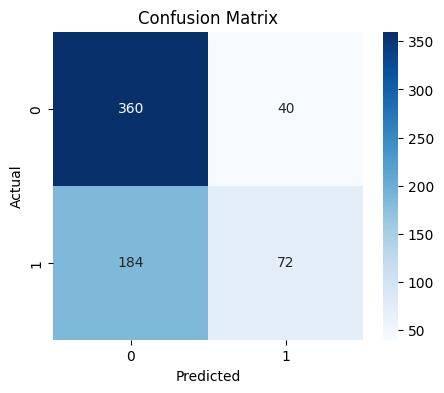


Classification Report

              precision    recall  f1-score   support

           0       0.66      0.90      0.76       400
           1       0.64      0.28      0.39       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656


Model Saved: water_potability_model.pkl
Results Saved: model_results.csv


In [23]:
# ================================
# WATER POTABILITY ML PIPELINE
# ================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ================================
# LOAD DATASET
# ================================

df = pd.read_csv("/content/water_potability.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ================================
# CHECK MISSING VALUES
# ================================

print("\nMissing Values:\n", df.isnull().sum())

# ================================
# SPLIT FEATURES AND TARGET
# ================================

X = df.drop("Potability", axis=1)
y = df["Potability"]

# ================================
# TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# PREPROCESSING PIPELINE
# ================================

preprocessor = Pipeline([

    ("imputer", SimpleImputer(strategy="mean")),   # handle missing values
    ("scaler", StandardScaler())                   # feature scaling

])

# ================================
# RANDOM FOREST MODEL
# ================================

rf_pipeline = Pipeline([

    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

rf_params = {

    "model__n_estimators":[200,300,500],
    "model__max_depth":[10,20,None],
    "model__min_samples_split":[2,5,10]

}

rf_grid = GridSearchCV(

    rf_pipeline,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1

)

rf_grid.fit(X_train,y_train)

print("\nBest RF Params:", rf_grid.best_params_)

rf_best = rf_grid.best_estimator_

# ================================
# XGBOOST MODEL
# ================================

xgb_pipeline = Pipeline([

    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

xgb_params = {

    "model__n_estimators":[200,400],
    "model__max_depth":[4,6,8],
    "model__learning_rate":[0.01,0.05,0.1]

}

xgb_grid = GridSearchCV(

    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1

)

xgb_grid.fit(X_train,y_train)

print("\nBest XGB Params:", xgb_grid.best_params_)

xgb_best = xgb_grid.best_estimator_

# ================================
# MODEL COMPARISON
# ================================

rf_pred = rf_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

rf_acc = accuracy_score(y_test,rf_pred)
xgb_acc = accuracy_score(y_test,xgb_pred)

print("\nRandomForest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

# ================================
# SELECT BEST MODEL
# ================================

if xgb_acc > rf_acc:
    best_model = xgb_best
    final_pred = xgb_pred
    model_name = "XGBoost"
    best_acc = xgb_acc
else:
    best_model = rf_best
    final_pred = rf_pred
    model_name = "RandomForest"
    best_acc = rf_acc

print("\nBest Model:", model_name)
print("Best Accuracy:", best_acc)

# ================================
# CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ================================
# CLASSIFICATION REPORT
# ================================

print("\nClassification Report\n")
print(classification_report(y_test, final_pred))

# ================================
# SAVE MODEL
# ================================

joblib.dump(best_model,"water_potability_model.pkl")

print("\nModel Saved: water_potability_model.pkl")

# ================================
# SAVE RESULTS
# ================================

results = pd.DataFrame({

    "Model":[model_name],
    "Accuracy":[best_acc]

})

results.to_csv("model_results.csv",index=False)

print("Results Saved: model_results.csv")

Dataset Shape: (3276, 10)
Feature count after engineering: 45
Balanced dataset: (3196, 45)
[LightGBM] [Info] Number of positive: 1598, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11475
[LightGBM] [Info] Number of data points in the train set: 3196, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model Accuracy: 0.625


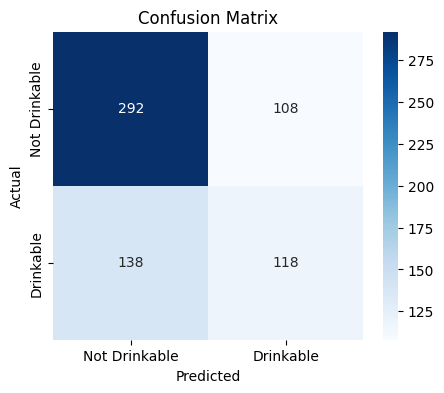


Classification Report

              precision    recall  f1-score   support

           0       0.68      0.73      0.70       400
           1       0.52      0.46      0.49       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656


Model saved: water_model.pkl
Results saved: results.csv


In [25]:
# ==========================================
# ADVANCED WATER POTABILITY PIPELINE
# ==========================================

!pip -q install lightgbm xgboost imbalanced-learn seaborn joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import VotingClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("/content/water_potability.csv")

X = df.drop("Potability", axis=1)
y = df["Potability"]

print("Dataset Shape:", df.shape)

# ==========================================
# HANDLE MISSING VALUES
# ==========================================

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# FEATURE ENGINEERING
# ==========================================

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X = poly.fit_transform(X)

print("Feature count after engineering:", X.shape[1])

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==========================================
# BALANCE DATASET
# ==========================================

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced dataset:", X_train.shape)

# ==========================================
# MODELS
# ==========================================

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

lgb = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=8
)

# ==========================================
# ENSEMBLE MODEL
# ==========================================

model = VotingClassifier(
    estimators=[
        ("xgb", xgb),
        ("lgb", lgb)
    ],
    voting="soft"
)

# ==========================================
# TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)

# ==========================================
# PREDICT
# ==========================================

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("\nModel Accuracy:", accuracy)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Drinkable","Drinkable"],
    yticklabels=["Not Drinkable","Drinkable"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ==========================================
# REPORT
# ==========================================

print("\nClassification Report\n")

print(classification_report(y_test, pred))

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(model,"water_model.pkl")

print("\nModel saved: water_model.pkl")

# ==========================================
# SAVE RESULTS
# ==========================================

results = pd.DataFrame({
    "Accuracy":[accuracy]
})

results.to_csv("results.csv",index=False)

print("Results saved: results.csv")